In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(r'/content/Unemployment in India.csv')
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
735,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
736,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
737,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
738,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [ ]:
# ## Remove the null rows

# df = df[df.Region.isnotnull()]
# df

### Data Understanding

In [ ]:
df.shape

(740, 7)

In [ ]:
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
735,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
736,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
737,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
738,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban
739,West Bengal,30-06-2020,Monthly,9.86,9088931.0,37.57,Urban


In [ ]:
df.sample(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
439,Delhi,31-05-2020,Monthly,45.78,2343783.0,28.28,Urban
258,Rajasthan,30-06-2019,Monthly,13.70,14610564.0,41.02,Rural
429,Delhi,31-07-2019,Monthly,14.68,5393091.0,42.34,Urban
435,Delhi,31-01-2020,Monthly,22.45,5647493.0,48.09,Urban
664,Tamil Nadu,31-01-2020,Monthly,2.05,11926995.0,37.64,Urban


In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 40.6+ KB


### Initial Checks on the Data

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


There is no missing data in this dataset


In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the data

In [ ]:
old = ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
new = ['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Rate', 'Area']
oldNewDict = dict(zip(old, new))
df.rename(columns=oldNewDict, inplace=True)

df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Rate', 'Area'],
      dtype='object')

In [ ]:
df['Frequency'].unique()

array([' Monthly', 'Monthly'], dtype=object)

In [ ]:
df.Frequency.replace({' Monthly':'Monthly'}, inplace = True)

In [ ]:
df['Frequency'].unique()

array(['Monthly'], dtype=object)

In [ ]:
df1 = df.copy()

In [ ]:
df.drop(columns = 'Frequency', inplace = True)

In [ ]:
df.columns

Index(['Region', 'Date', 'Unemployment_Rate', 'Employed', 'Labour_Rate',
       'Area'],
      dtype='object')

In [ ]:
for col in df.columns:
  if len(df[col].unique()) < 35:
    print(col, ":-->\t", len(df[col].unique()), "-->\t", df[col].unique())
    print()

Region :-->	 28 -->	 ['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Date :-->	 14 -->	 [' 31-05-2019' ' 30-06-2019' ' 31-07-2019' ' 31-08-2019' ' 30-09-2019'
 ' 31-10-2019' ' 30-11-2019' ' 31-12-2019' ' 31-01-2020' ' 29-02-2020'
 ' 31-03-2020' ' 30-04-2020' ' 31-05-2020' ' 30-06-2020']

Area :-->	 2 -->	 ['Rural' 'Urban']



As per the observation, Region and Area columns can be considered as Categorical Data.
- Region: 28 Regions under India
- Area: 2 Types of Area

In [ ]:
df.Region.value_counts()

,count
Region,
Andhra Pradesh,28
Bihar,28
Chhattisgarh,28
Delhi,28
Karnataka,28
Gujarat,28
Haryana,28
Himachal Pradesh,28
Jharkhand,28


In [ ]:
df.dtypes

,0
Region,object
Date,object
Unemployment_Rate,float64
Employed,float64
Labour_Rate,float64
Area,object


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)

In [ ]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Unemployment_Rate,float64
Employed,float64
Labour_Rate,float64
Area,object


In [ ]:
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Unemployment_Rate,float64
Employed,float64
Labour_Rate,float64
Area,object
Year,int32
Month,int32


In [ ]:
df.columns

Index(['Region', 'Date', 'Unemployment_Rate', 'Employed', 'Labour_Rate',
       'Area', 'Year', 'Month'],
      dtype='object')

In [ ]:
# Rearranging of the columns
df = df[['Region', 'Date', 'Month', 'Year', 'Unemployment_Rate', 'Employed', 'Labour_Rate', 'Area']]
df

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area
0,Andhra Pradesh,2019-05-31,5,2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,6,2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,7,2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,8,2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,9,2019,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...,...
735,West Bengal,2020-02-29,2,2020,7.55,10871168.0,44.09,Urban
736,West Bengal,2020-03-31,3,2020,6.67,10806105.0,43.34,Urban
737,West Bengal,2020-04-30,4,2020,15.63,9299466.0,41.20,Urban
738,West Bengal,2020-05-31,5,2020,15.22,9240903.0,40.67,Urban


In [ ]:
a = df.groupby(['Area', 'Region'])['Unemployment_Rate'].mean()
a

Area   Region          
Rural  Andhra Pradesh       5.526429
       Assam                4.490833
       Bihar               16.770000
       Chhattisgarh         6.628571
       Delhi               15.258571
       Goa                  8.390000
       Gujarat              5.917143
       Haryana             25.012857
       Himachal Pradesh    15.504286
       Jammu & Kashmir     14.951818
       Jharkhand           15.221429
       Karnataka            7.224286
       Kerala              10.341429
       Madhya Pradesh       5.653571
       Maharashtra          6.810000
       Meghalaya            2.475000
       Odisha               6.612857
       Puducherry           7.263333
       Punjab              11.925000
       Rajasthan           10.927143
       Sikkim               5.080000
       Tamil Nadu           8.775714
       Telangana            7.863571
       Tripura             27.166429
       Uttar Pradesh       10.208571
       Uttarakhand          4.882308
       West Bengal          7.572143
Urban  Andhra Pradesh       9.427857
       Assam                8.088571
       Bihar               21.066429
       Chandigarh          15.991667
       Chhattisgarh        11.852143
       Delhi               17.732143
       Goa                 10.158333
       Gujarat              7.410714
       Haryana             27.553571
       Himachal Pradesh    21.576429
       Jammu & Kashmir     17.549000
       Jharkhand           25.948571
       Karnataka            6.127857
       Kerala               9.906429
       Madhya Pradesh       9.159286
       Maharashtra          8.305000
       Meghalaya            7.301538
       Odisha               4.702857
       Puducherry          12.745000
       Punjab              12.137143
       Rajasthan           17.189286
       Sikkim               8.153333
       Tamil Nadu           9.792857
       Telangana            7.612143
       Tripura             29.534286
       Uttar Pradesh       14.894286
       Uttarakhand          8.162143
       West Bengal          8.677143
Name: Unemployment_Rate, dtype: float64

In [ ]:
a = a.unstack()
a

Region,Andhra Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,...,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal
Area,,,,,,,,,,,,,,,,,,,,,
Rural,5.526429,4.490833,16.770000,NaN,6.628571,15.258571,8.390000,5.917143,25.012857,15.504286,...,7.263333,11.925000,10.927143,5.080000,8.775714,7.863571,27.166429,10.208571,4.882308,7.572143
Urban,9.427857,8.088571,21.066429,15.991667,11.852143,17.732143,10.158333,7.410714,27.553571,21.576429,...,12.745000,12.137143,17.189286,8.153333,9.792857,7.612143,29.534286,14.894286,8.162143,8.677143


Notes:
- For Chandigarh, we don't have Rural population as per the dataset

In [ ]:
b = a.T
b['Rural_Urban_Gap'] = b['Urban'] - b['Rural']
b

Area,Rural,Urban,Rural_Urban_Gap
Region,,,
Andhra Pradesh,5.526429,9.427857,3.901429
Assam,4.490833,8.088571,3.597738
Bihar,16.770000,21.066429,4.296429
Chandigarh,NaN,15.991667,NaN
Chhattisgarh,6.628571,11.852143,5.223571
Delhi,15.258571,17.732143,2.473571
Goa,8.390000,10.158333,1.768333
Gujarat,5.917143,7.410714,1.493571
Haryana,25.012857,27.553571,2.540714


In [ ]:
df.Year.unique()

array([2019, 2020], dtype=int32)

In [ ]:
## SQL Task

# Top 5 regions with highest average unemployment rate during 2020–21
# SELECT Region, AVG("Unemployment_Rate") AS Average_Unemployment_Rate FROM df
# WHERE YEAR IN (2020)
# GROUPBY Region
# ORDER BY Average_Unemployment_Rate LIMIT 5;

#### Exploratory Data Analysis
- Line charts of unemployment rate over time for select states (e.g., Delhi, Maharashtra)
- Bar charts comparing rural vs urban unemployment rates
- Heatmap: region × year showing unemployment intensity
- Box plots: participation rate distribution across regions
- Time series of employment and participation rates
#### Descriptive Statistics
- Mean, median, standard deviation for unemployment and participation
- Compute coefficient of variation by region
- Rank top 3 states with highest variability in unemployment
- Identify months/years with extreme peaks or dips aka outliers (IQR method)
- Calculate correlation between unemployment rate and participation rate

In [ ]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

### Line charts of unemployment rate over time for select states

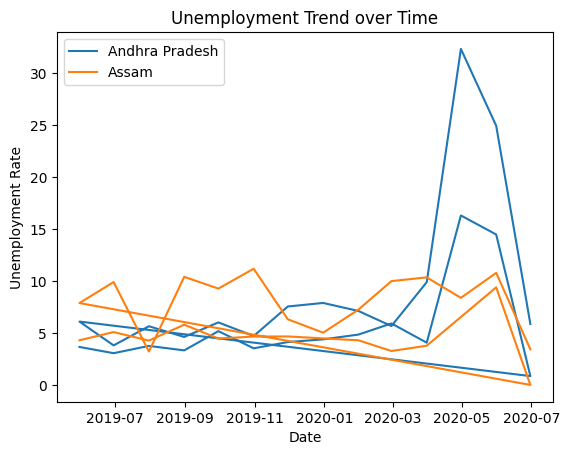

In [ ]:
# selected_states = ['Delhi', 'Maharashtra', 'Tamil Nadu', 'West Bengal']
selected_states = df['Region'].unique()[:2]

plt.figure()
for state in selected_states:
  temp = df[df['Region'] == state]
  plt.plot(temp['Date'], temp['Unemployment_Rate'], label = state)
plt.legend()
plt.title('Unemployment Trend over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()

### Bar charts comparing rural vs urban unemployment rates

In [ ]:
area_avg = df.groupby('Area')['Unemployment_Rate'].mean()
area_avg

,Unemployment_Rate
Area,
Rural,10.324791
Urban,13.166614


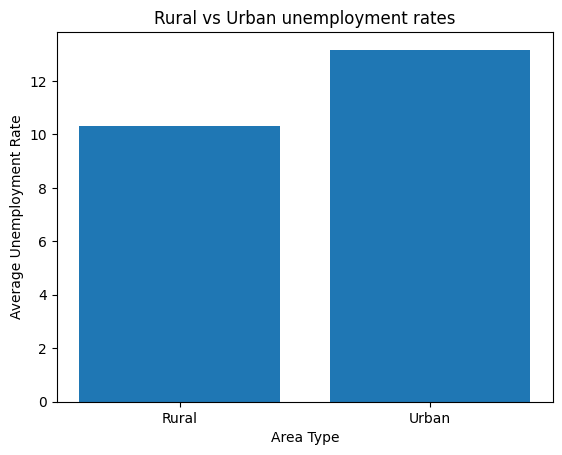

In [ ]:
plt.figure()
plt.bar(area_avg.index, area_avg.values)
# area_avg.plot(kind = 'bar')
plt.title('Rural vs Urban unemployment rates')
plt.xlabel('Area Type')
plt.ylabel('Average Unemployment Rate')
plt.show()

### Heatmap: region × year showing unemployment intensity

In [ ]:
pivot = df.pivot_table(values = 'Unemployment_Rate', index = 'Region', columns = 'Year', aggfunc = 'mean')
pivot

Year,2019,2020
Region,,
Andhra Pradesh,4.826875,11.010833
Assam,6.420667,6.438182
Bihar,13.882500,25.632500
Chandigarh,15.822500,16.330000
Chhattisgarh,7.346875,11.765000
Delhi,13.750625,20.155000
Goa,9.346250,9.130000
Gujarat,4.979375,8.910000
Haryana,22.798750,30.929167


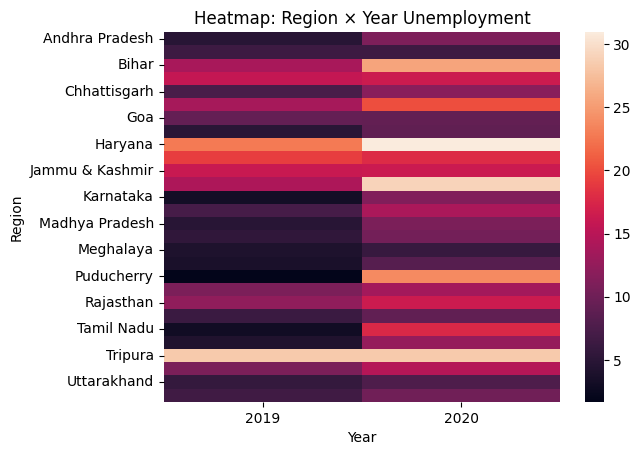

In [ ]:
plt.figure()
sns.heatmap(pivot)
plt.title('Heatmap: Region × Year Unemployment')
plt.show()

### Box plots: Participation rate distribution across regions

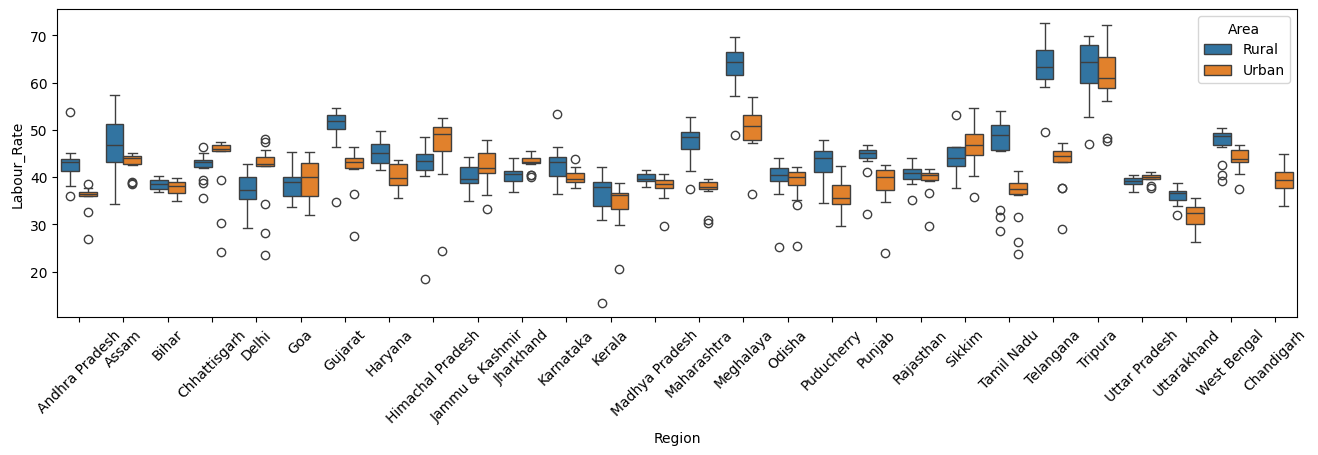

In [ ]:
plt.figure(figsize=(16,4))
sns.boxplot(x = 'Region', y = 'Labour_Rate', data = df, hue = 'Area')
plt.xticks(rotation = 45)
plt.show()

### Time series of employment and participation rates

In [ ]:
df2 = df.sort_values('Date')
df2

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area
0,Andhra Pradesh,2019-05-31,5,2019,3.65,11999139.0,43.24,Rural
290,Telangana,2019-05-31,5,2019,2.23,11053353.0,61.74,Rural
276,Tamil Nadu,2019-05-31,5,2019,0.97,15844698.0,49.44,Rural
257,Rajasthan,2019-05-31,5,2019,4.03,15226005.0,38.52,Rural
243,Punjab,2019-05-31,5,2019,9.17,6088547.0,44.79,Rural
...,...,...,...,...,...,...,...,...
275,Sikkim,2020-06-30,6,2020,5.81,141313.0,42.36,Rural
289,Tamil Nadu,2020-06-30,6,2020,2.06,10169115.0,31.49,Rural
303,Telangana,2020-06-30,6,2020,19.30,8891181.0,58.97,Rural
121,Himachal Pradesh,2020-06-30,6,2020,1.12,2230075.0,41.20,Rural


In [ ]:
ts = df.groupby('Date')[['Unemployment_Rate', 'Employed', 'Labour_Rate']].mean()
ts

,Unemployment_Rate,Employed,Labour_Rate
Date,,,
2019-05-31,8.874259,7.410148e+06,43.902963
2019-06-30,9.303333,7.358642e+06,43.750556
2019-07-31,9.033889,7.404425e+06,43.706667
2019-08-31,9.637925,7.539815e+06,43.646792
2019-09-30,9.051731,7.739464e+06,44.301346
2019-10-31,9.900909,7.298382e+06,44.001273
2019-11-30,9.868364,7.273661e+06,44.110545
2019-12-31,9.497358,7.377388e+06,43.667358
2020-01-31,9.950755,7.677344e+06,44.051321


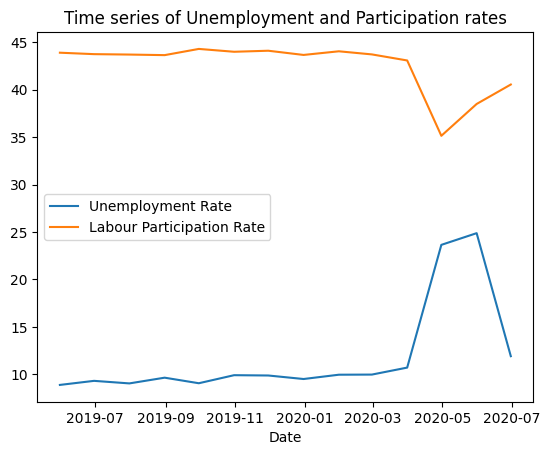

In [ ]:
plt.figure()
# plt.plot(ts.index, ts['Employed']/1000000,          label = 'Employed People')    # Division by 10^6 done to scale down the values
plt.plot(ts.index, ts['Unemployment_Rate'], label = 'Unemployment Rate')
plt.plot(ts.index, ts['Labour_Rate'],       label = 'Labour Participation Rate')
plt.legend()
plt.title('Time series of Unemployment and Participation rates')
plt.xlabel('Date')
plt.show()

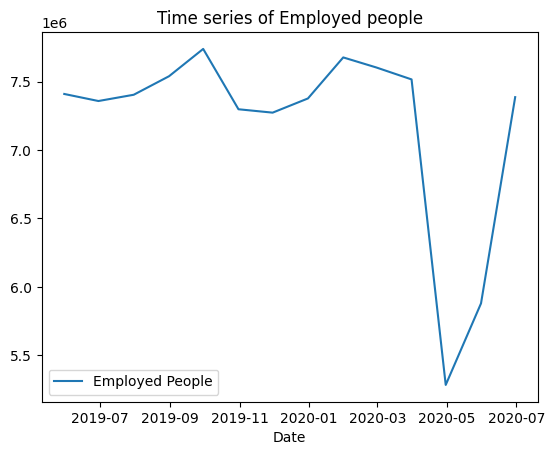

In [ ]:
plt.figure()
plt.plot(ts.index, ts['Employed'], label = 'Employed People')
plt.legend()
plt.title('Time series of Employed people')
plt.xlabel('Date')
plt.show()

## Descriptive Statistics

#### Mean, median, standard deviation for unemployment and participation

In [ ]:
df[['Unemployment_Rate', 'Labour_Rate']].describe().loc[['mean', 'std', '50%']].T

,mean,std,50%
Unemployment_Rate,11.787946,10.721298,8.35
Labour_Rate,42.630122,8.111094,41.16


#### Compute coefficient of variation of Unemployment Rate by region

In [ ]:
cvByRegion = df.groupby('Region')['Unemployment_Rate'].agg(mean = 'mean', std = 'std')
cvByRegion['CV'] = cvByRegion['std']/cvByRegion['mean']
cvByRegion.sort_values(by = 'CV', inplace = True, ascending = False)
cvByRegion

,mean,std,CV
Region,,,
Puducherry,10.215000,24.106816,2.359943
Tamil Nadu,9.284286,14.455317,1.556966
Karnataka,6.676071,8.103508,1.213814
Telangana,7.737857,8.544484,1.104244
Madhya Pradesh,7.406429,7.757720,1.047431
Odisha,5.657857,5.553891,0.981624
Andhra Pradesh,7.477143,6.852073,0.916403
Meghalaya,4.798889,4.102673,0.854921
Jharkhand,20.585000,16.674746,0.810044


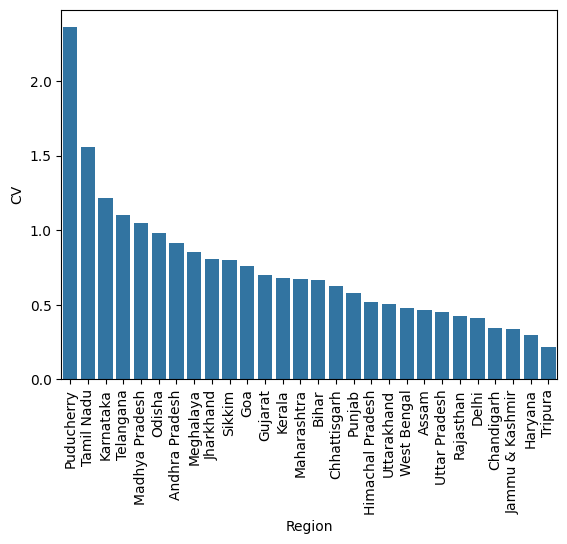

In [ ]:
plt.figure()
sns.barplot(x = cvByRegion.index, y = cvByRegion['CV'])
plt.xticks(rotation = 90)
plt.show()

In [ ]:
df

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area
0,Andhra Pradesh,2019-05-31,5,2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,6,2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,7,2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,8,2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,9,2019,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...,...
735,West Bengal,2020-02-29,2,2020,7.55,10871168.0,44.09,Urban
736,West Bengal,2020-03-31,3,2020,6.67,10806105.0,43.34,Urban
737,West Bengal,2020-04-30,4,2020,15.63,9299466.0,41.20,Urban
738,West Bengal,2020-05-31,5,2020,15.22,9240903.0,40.67,Urban


In [ ]:
df['Prev_Unemployment_Rate'] = df.groupby('Region')['Unemployment_Rate'].shift(1)
df

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area,Prev_Unemployment_Rate
0,Andhra Pradesh,2019-05-31,5,2019,3.65,11999139.0,43.24,Rural,NaN
1,Andhra Pradesh,2019-06-30,6,2019,3.05,11755881.0,42.05,Rural,3.65
2,Andhra Pradesh,2019-07-31,7,2019,3.75,12086707.0,43.50,Rural,3.05
3,Andhra Pradesh,2019-08-31,8,2019,3.32,12285693.0,43.97,Rural,3.75
4,Andhra Pradesh,2019-09-30,9,2019,5.17,12256762.0,44.68,Rural,3.32
...,...,...,...,...,...,...,...,...,...
735,West Bengal,2020-02-29,2,2020,7.55,10871168.0,44.09,Urban,7.27
736,West Bengal,2020-03-31,3,2020,6.67,10806105.0,43.34,Urban,7.55
737,West Bengal,2020-04-30,4,2020,15.63,9299466.0,41.20,Urban,6.67
738,West Bengal,2020-05-31,5,2020,15.22,9240903.0,40.67,Urban,15.63


In [ ]:
round(df['Prev_Unemployment_Rate'].loc[1:5].mean(), 2)

np.float64(3.79)

In [ ]:
df = df.dropna()
# df.loc[0, 'Prev_Unemployment_Rate'] = round(df['Prev_Unemployment_Rate'].loc[1:5].mean(), 2)
df

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area,Prev_Unemployment_Rate
1,Andhra Pradesh,2019-06-30,6,2019,3.05,11755881.0,42.05,Rural,3.65
2,Andhra Pradesh,2019-07-31,7,2019,3.75,12086707.0,43.50,Rural,3.05
3,Andhra Pradesh,2019-08-31,8,2019,3.32,12285693.0,43.97,Rural,3.75
4,Andhra Pradesh,2019-09-30,9,2019,5.17,12256762.0,44.68,Rural,3.32
5,Andhra Pradesh,2019-10-31,10,2019,3.52,12017412.0,43.01,Rural,5.17
...,...,...,...,...,...,...,...,...,...
735,West Bengal,2020-02-29,2,2020,7.55,10871168.0,44.09,Urban,7.27
736,West Bengal,2020-03-31,3,2020,6.67,10806105.0,43.34,Urban,7.55
737,West Bengal,2020-04-30,4,2020,15.63,9299466.0,41.20,Urban,6.67
738,West Bengal,2020-05-31,5,2020,15.22,9240903.0,40.67,Urban,15.63


In [ ]:
df[df.Prev_Unemployment_Rate.isnull()]

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area,Prev_Unemployment_Rate


### Regression

In [ ]:
df.columns

Index(['Region', 'Date', 'Month', 'Year', 'Unemployment_Rate', 'Employed',
       'Labour_Rate', 'Area', 'Prev_Unemployment_Rate'],
      dtype='object')

In [ ]:
X = df[['Prev_Unemployment_Rate', 'Labour_Rate', 'Year', 'Month']]     # Relevant Features for the target variable
y = df['Unemployment_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [ ]:
modelLR = LinearRegression()
modelLR.fit(X_train, y_train)
yPredictionLR = model.predict(X_test)       # Predicted values of the test data

In [ ]:
modelRF = RandomForestRegressor()
modelRF.fit(X_train, y_train)
yPredictionRF = modelRF.predict(X_test)       # Predicted values of the test data

In [ ]:
print('Linear Regression: ')
print('MAE \t-->', mean_absolute_error(y_test, yPredictionLR))
print('r2 \t-->', r2_score(y_test, yPredictionLR))

print()

print('Random Forrest Regressor: ')
print('MAE \t-->', mean_absolute_error(y_test, yPredictionRF))
print('r2 \t-->', r2_score(y_test, yPredictionRF))



# Lower the MAE, better the model
# Higher R2, better

Linear Regression: 
MAE 	--> 6.126084288380031
r2 	--> 0.19952961811402437

Random Forrest Regressor: 
MAE 	--> 5.385874825174826
r2 	--> 0.29944857985154183


## Classification

In [ ]:
df.Unemployment_Rate.unique()

array([ 3.05,  3.75,  3.32,  5.17,  3.52,  4.12,  4.38,  4.84,  5.91,
        4.06, 16.29, 14.46,  0.85,  5.08,  4.26,  5.79,  4.46,  4.65,
        4.66,  4.29,  3.26,  3.77,  9.38,  0.  , 10.2 , 13.44, 11.  ,
        8.87, 12.47, 12.4 , 10.16,  9.13,  9.61, 15.39, 45.09, 47.26,
       20.49,  6.76,  4.54,  4.64,  8.33,  6.96,  2.77,  6.11,  9.89,
        7.89,  7.31,  7.64, 10.14,  9.33, 11.07, 17.18, 12.5 , 15.84,
       11.11, 16.97, 13.48, 13.81, 15.18, 20.69, 22.76, 21.14,  5.45,
       10.98,  1.98,  3.61,  7.21, 23.71,  3.54,  5.38, 15.91, 20.  ,
        4.77,  4.58,  3.7 ,  6.29,  4.91,  4.68,  3.46,  5.35,  6.64,
        7.59, 12.  , 14.58,  1.41, 23.08, 16.22, 30.94, 16.36, 24.17,
       16.59, 29.56, 16.21, 27.19, 23.92, 41.61, 34.22, 35.57, 11.43,
       20.59, 18.56, 15.98, 15.81, 22.86, 19.46, 16.67, 15.42, 17.71,
        2.13, 25.64,  1.12, 12.09, 13.67, 11.32, 19.27, 14.73, 22.19,
       21.23, 16.  ,  2.22, 18.97,  8.46,  9.98, 12.06,  7.12,  6.57,
        8.07, 15.15,

In [ ]:
df.Unemployment_Rate.median()

8.445

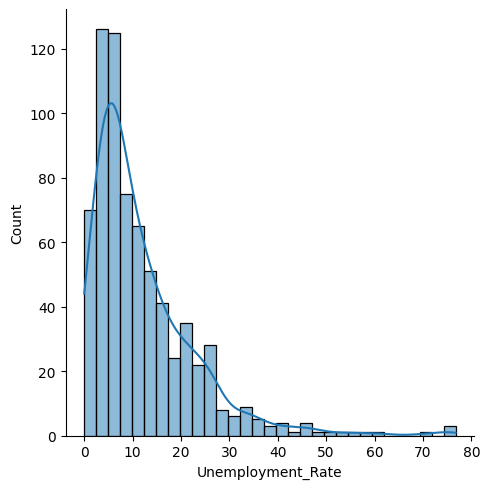

In [ ]:
sns.displot(x = df.Unemployment_Rate, kde = True)

In [ ]:
def classify(data):
  if   data < 5 : return 'Low'
  elif data < 12: return 'Medium'
  else          : return 'High'

df['Unemployment_Category'] = df.Unemployment_Rate.apply(classify)
df

,Region,Date,Month,Year,Unemployment_Rate,Employed,Labour_Rate,Area,Prev_Unemployment_Rate,Unemployment_Category
1,Andhra Pradesh,2019-06-30,6,2019,3.05,11755881.0,42.05,Rural,3.65,Low
2,Andhra Pradesh,2019-07-31,7,2019,3.75,12086707.0,43.50,Rural,3.05,Low
3,Andhra Pradesh,2019-08-31,8,2019,3.32,12285693.0,43.97,Rural,3.75,Low
4,Andhra Pradesh,2019-09-30,9,2019,5.17,12256762.0,44.68,Rural,3.32,Medium
5,Andhra Pradesh,2019-10-31,10,2019,3.52,12017412.0,43.01,Rural,5.17,Low
...,...,...,...,...,...,...,...,...,...,...
735,West Bengal,2020-02-29,2,2020,7.55,10871168.0,44.09,Urban,7.27,Medium
736,West Bengal,2020-03-31,3,2020,6.67,10806105.0,43.34,Urban,7.55,Medium
737,West Bengal,2020-04-30,4,2020,15.63,9299466.0,41.20,Urban,6.67,High
738,West Bengal,2020-05-31,5,2020,15.22,9240903.0,40.67,Urban,15.63,High


In [ ]:
df.columns

Index(['Region', 'Date', 'Month', 'Year', 'Unemployment_Rate', 'Employed',
       'Labour_Rate', 'Area', 'Prev_Unemployment_Rate',
       'Unemployment_Category'],
      dtype='object')

In [ ]:
# Prepare Data
P = df[['Prev_Unemployment_Rate', 'Labour_Rate', 'Year', 'Month']]
q = df['Unemployment_Category']

P_train, P_test, q_train, q_test = train_test_split(P, q, test_size = 0.2)

In [ ]:
model1 = DecisionTreeClassifier()
model1.fit(P_train, q_train)

q_pred = model1.predict(P_test)                # Predicted values of the test data

In [ ]:
print('Accuracy\n', accuracy_score(q_test, q_pred))
print()
print('Confusion Matrix\n', confusion_matrix(q_test, q_pred))
print()
print('Classification Report:\n', classification_report(q_test, q_pred))

Accuracy
 0.6153846153846154

Confusion Matrix
 [[35  5  8]
 [ 8 25 13]
 [11 10 28]]

Classification Report:
               precision    recall  f1-score   support

        High       0.65      0.73      0.69        48
         Low       0.62      0.54      0.58        46
      Medium       0.57      0.57      0.57        49

    accuracy                           0.62       143
   macro avg       0.61      0.61      0.61       143
weighted avg       0.61      0.62      0.61       143



In [ ]:
importance = pd.Series(model1.feature_importances_, index = P.columns)
print(importance.sort_values(ascending = False))

Prev_Unemployment_Rate    0.505742
Labour_Rate               0.338922
Month                     0.127950
Year                      0.027386
dtype: float64


Unemployment Rate largely depends on the Labour Participation Rate of the region/country.